# ML Engineering Portfolio — Walkthrough

Reproducible demonstrations of the production-ML methods that decide whether a model that looks good offline actually holds up live. Each section runs a small, deterministic experiment on synthetic data and shows the result.

**Author:** Kyle Reynolds

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from IPython.display import Image

## 1 · Leakage-safe time-series validation

Random K-fold cross-validation leaks future information on time-ordered data — it shuffles past and future together, so the model is scored on conditions it has already seen. Walk-forward validation trains on the past and tests on the future, the way the model is actually deployed. On data with concept drift, K-fold reports an over-optimistic score.

In [2]:
import walk_forward_validation as wfv
r = wfv.evaluate()
print(f"Random K-fold AUC : {r['kfold_mean']:.3f}")
print(f"Walk-forward AUC  : {r['walk_mean']:.3f}")
print(f"Leakage optimism  : {r['optimism']:+.3f} AUC")

Random K-fold AUC : 0.814
Walk-forward AUC  : 0.788
Leakage optimism  : +0.026 AUC


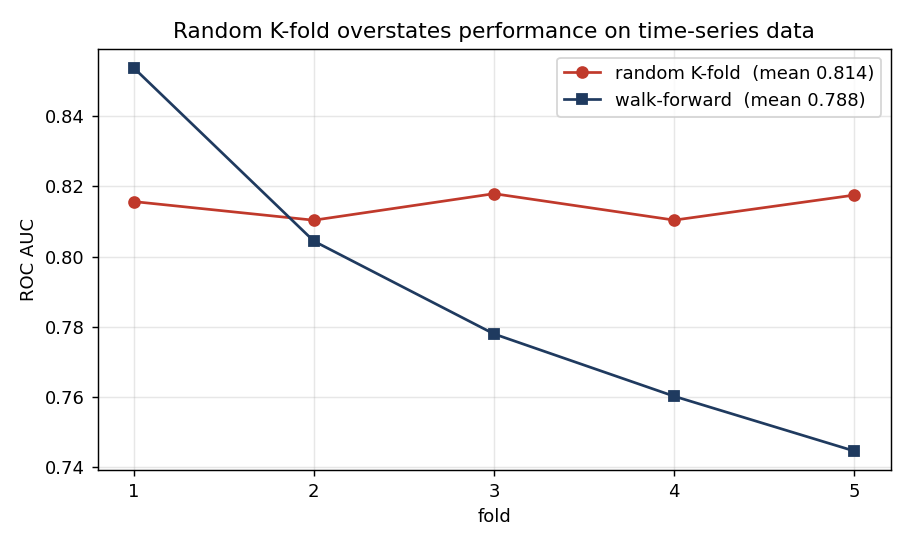

In [3]:
Image('../images/walk_forward_validation.png')

## 2 · Probability calibration

A model can rank well (high AUC) yet output untrustworthy probabilities. Isotonic calibration fit on a held-out set fixes the probability scale without changing the ranking, lowering the Brier score.

In [4]:
import probability_calibration as cal
r = cal.evaluate()
print(f"AUC (unchanged)    : {r['auc']:.3f}")
print(f"Brier uncalibrated : {r['brier_uncal']:.4f}")
print(f"Brier calibrated   : {r['brier_cal']:.4f}")

AUC (unchanged)    : 0.962
Brier uncalibrated : 0.0697
Brier calibrated   : 0.0625


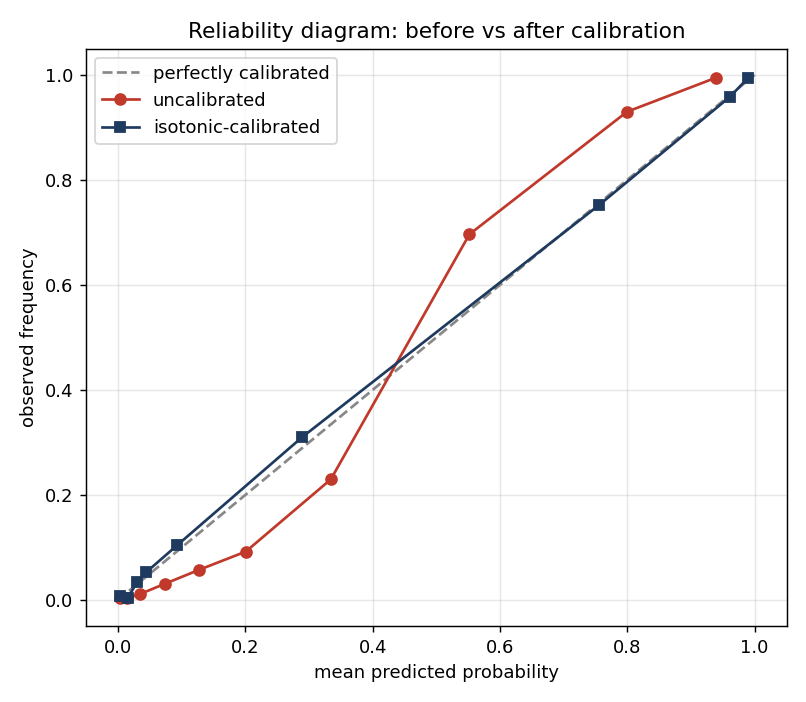

In [5]:
Image('../images/probability_calibration.png')

## 3 · SHAP-driven feature selection

Ranking features by mean absolute SHAP value and keeping only the top-k preserves performance while shrinking the model. Here 40 features reduce to ~10 with no loss of AUC.

In [6]:
import shap_feature_selection as sfs
r = sfs.evaluate()
print(f"Top-10 features AUC : {r['top10_auc']:.3f}")
print(f"All {r['n_features']} features AUC : {r['full_auc']:.3f}")

Top-10 features AUC : 0.976
All 40 features AUC : 0.975


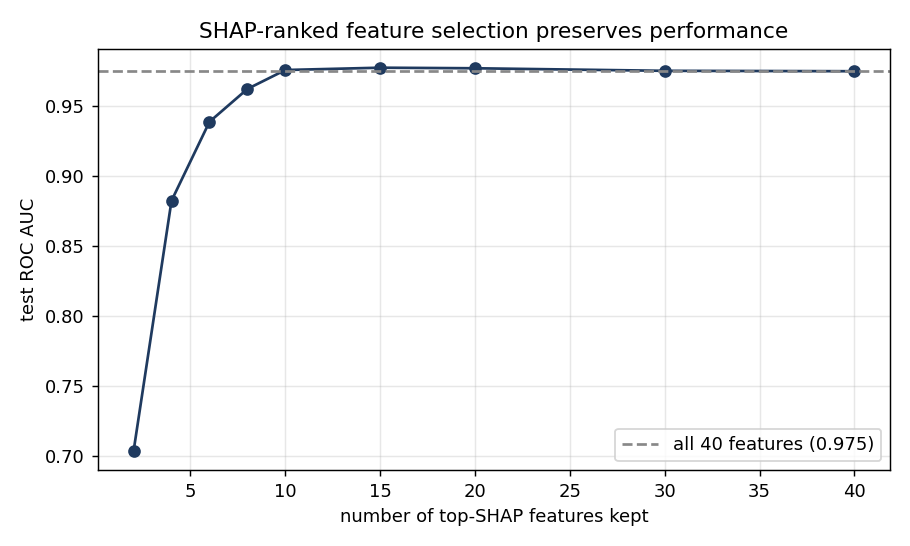

In [7]:
Image('../images/shap_feature_selection.png')

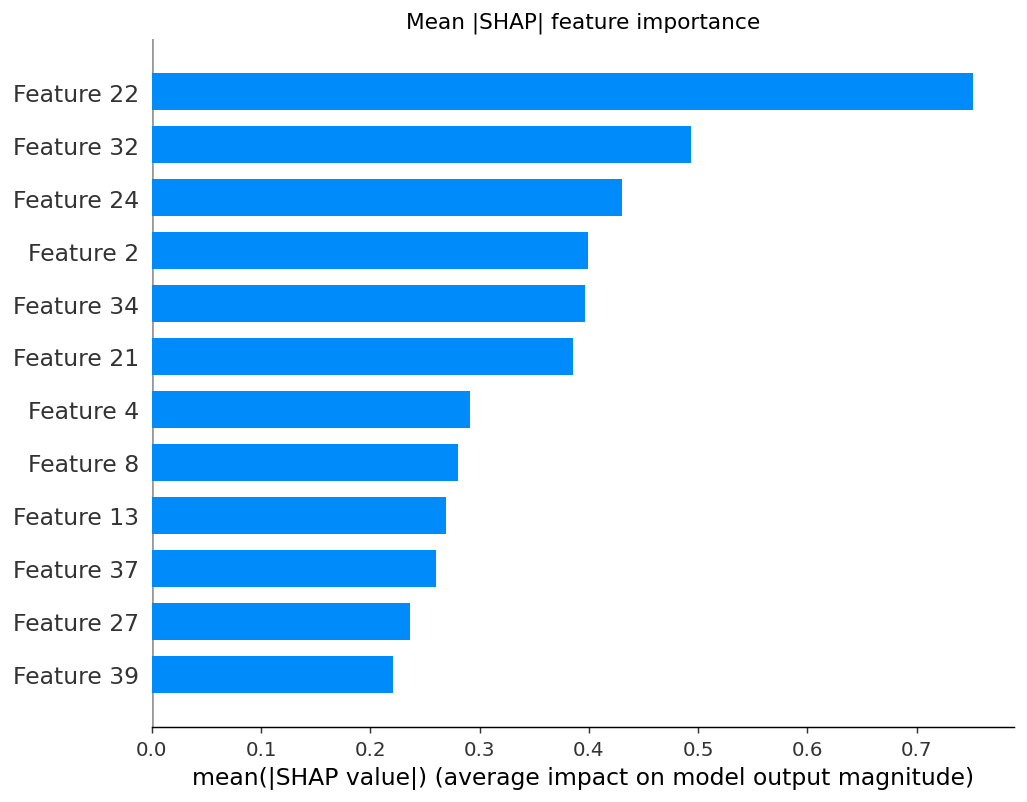

In [8]:
Image('../images/shap_importance.png')

## 4 · Feature drift detection

A deployed model degrades when live data drifts from training data. Population Stability Index (PSI) and the Kolmogorov-Smirnov test flag which features have shifted — here feature_0 (mean shift) and feature_2 (scale change) trip the alert threshold, while the stable features do not.

In [9]:
import drift_detection as drift
r = drift.evaluate()
for name, psi in zip(r['names'], r['psi']):
    print(f"{name:<12} PSI {psi:6.3f}")
print('flagged:', ', '.join(r['flagged']))

feature_0    PSI  1.262
feature_1    PSI  0.003
feature_2    PSI  0.370
feature_3    PSI  0.004
feature_4    PSI  0.237
feature_5    PSI  0.003
flagged: feature_0, feature_2


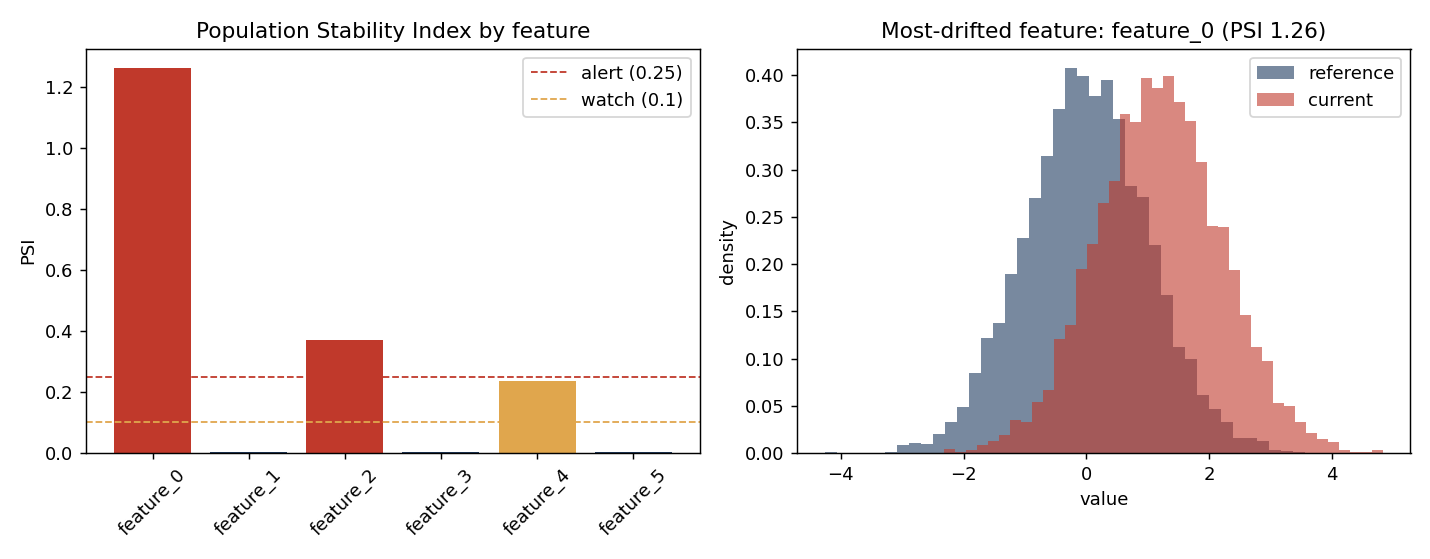

In [10]:
Image('../images/drift_detection.png')

---

Every result above is deterministic (fixed seeds) and reproduced by the scripts in [`src/`](../src). Run them all with `python run_all.py`.